# Proyecto Final
## Clasificación automática y descubrimiento de sub-temas en quejas de consumidores financieros
**Camino B:** Supervisado + NLP + No supervisado

Dataset: CFPB Consumer Complaint Database (2011–2019)

## Dataset y alcance

- **Fuente:** CFPB Consumer Complaint Database (`rows.csv`).
- **Decisión clave:** `Consumer complaint narrative` está vacía en ~68–70% de filas.
  Para NLP usamos solo filas con narrativa (documentamos cuántas quedan).
- **Product:** unificamos categorías renombradas y nos quedamos con el **Top 7 + Otros**.
- **Objetivo:** enrutamiento automático de quejas + detección de sub-temas emergentes.

In [71]:
import warnings
warnings.filterwarnings('ignore')

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score, silhouette_score,
)
from sklearn.model_selection import train_test_split

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
DATA_PATH = Path('rows.csv')
US_STATES_URL = 'https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json'

## Análisis de datos y metadatos

In [72]:
DATA_DICTIONARY = {
    'Date received': 'Fecha en que el CFPB recibió la queja.',
    'Product': 'Categoría principal del producto o servicio financiero.',
    'Sub-product': 'Subcategoría del producto.',
    'Issue': 'Problema reportado por el consumidor.',
    'Sub-issue': 'Detalle del problema dentro del Issue.',
    'Consumer complaint narrative': 'Texto libre de la queja (puede estar vacío).',
    'Company public response': 'Respuesta pública de la empresa (puede estar vacía).',
    'Company': 'Institución financiera señalada.',
    'State': 'Estado de EE.UU. del consumidor.',
    'ZIP code': 'Código postal del consumidor.',
}

usecols = list(DATA_DICTIONARY.keys())
df_raw = pd.read_csv(DATA_PATH, usecols=usecols, low_memory=False)
df_raw['Date received'] = pd.to_datetime(df_raw['Date received'], errors='coerce')
df = df_raw.copy()

print('Shape:', df.shape)
meta = pd.DataFrame({
    'columna': df.columns,
    'tipo': df.dtypes.astype(str).values,
    'nulos_%': (df.isna().mean() * 100).round(2).values,
    'descripcion': [DATA_DICTIONARY[c] for c in df.columns],
})
meta

Shape: (1282355, 10)


,columna,tipo,nulos_%,descripcion
0,Date received,datetime64[ns],0.00,Fecha en que el CFPB recibió la queja.
1,Product,object,0.00,Categoría principal del producto o servicio fi...
2,Sub-product,object,18.34,Subcategoría del producto.
3,Issue,object,0.00,Problema reportado por el consumidor.
4,Sub-issue,object,41.42,Detalle del problema dentro del Issue.
5,Consumer complaint narrative,object,70.09,Texto libre de la queja (puede estar vacío).
6,Company public response,object,64.98,Respuesta pública de la empresa (puede estar v...
7,Company,object,0.00,Institución financiera señalada.
8,State,object,1.51,Estado de EE.UU. del consumidor.
9,ZIP code,object,8.99,Código postal del consumidor.


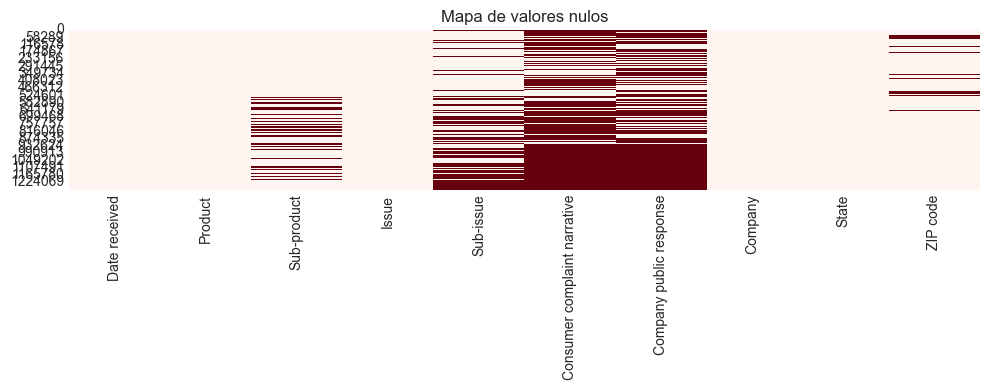

Duplicados exactos: 27070
Rango de fechas: 2011-12-01 00:00:00 → 2019-05-10 00:00:00
Narrativas no nulas: 383564 (29.9%)


In [73]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, cmap='Reds')
plt.title('Mapa de valores nulos')
plt.tight_layout()
plt.show()

print('Duplicados exactos:', df.duplicated().sum())
print('Rango de fechas:', df['Date received'].min(), '→', df['Date received'].max())
print('Narrativas no nulas:', df['Consumer complaint narrative'].notna().sum(),
      f"({df['Consumer complaint narrative'].notna().mean()*100:.1f}%)")

**Interpretación metadatos:** La narrativa y la respuesta pública concentran la mayoría de nulos. El EDA agregado puede usar todo el dataset; el NLP solo filas con texto.

### Preparación y limpieza de datos 

El CFPB renombró categorías de `Product` a lo largo de los años. Unificamos variantes equivalentes antes de modelar.

In [74]:
PRODUCT_UNIFICATION = {
    'Credit reporting, credit repair services, or other personal consumer reports': 'Credit reporting',
    'Credit card or prepaid card': 'Credit card',
    'Checking or savings account': 'Bank account or service',
}

TOP_PRODUCTS = [
    'Credit reporting', 'Mortgage', 'Debt collection', 'Credit card',
    'Bank account or service', 'Student loan', 'Consumer Loan',
]

print('Product ORIGINAL (top 10):')
display(df_raw['Product'].value_counts().head(10))

df['Product_unified'] = df['Product'].replace(PRODUCT_UNIFICATION)
df.loc[~df['Product_unified'].isin(TOP_PRODUCTS), 'Product_unified'] = 'Otros'

print('\nProduct UNIFICADO (top 10):')
display(df['Product_unified'].value_counts().head(10))

Product ORIGINAL (top 10):


Product
Mortgage                                                                        278098
Debt collection                                                                 244873
Credit reporting, credit repair services, or other personal consumer reports    225978
Credit reporting                                                                140432
Credit card                                                                      89190
Bank account or service                                                          86206
Student loan                                                                     51685
Credit card or prepaid card                                                      47653
Checking or savings account                                                      40641
Consumer Loan                                                                    31605
Name: count, dtype: int64


Product UNIFICADO (top 10):


Product_unified
Credit reporting           366410
Mortgage                   278098
Debt collection            244873
Credit card                136843
Bank account or service    126847
Student loan                51685
Otros                       45994
Consumer Loan               31605
Name: count, dtype: int64

**Por qué unificamos:** *Credit reporting* aparecía fragmentado en dos etiquetas históricas; lo mismo con *Credit card* y cuentas bancarias. Sin esto, el clasificador vería clases artificiales.

In [75]:
narr = df.loc[df['Consumer complaint narrative'].notna(), 'Consumer complaint narrative']
pct_xxxx = narr.str.contains(r'X{2,}', regex=True, na=False).mean() * 100
print(f'{pct_xxxx:.1f}% de narrativas contienen enmascaramiento XXXX (datos personales redactados)')

ejemplos_xxxx = narr[narr.str.contains('XXXX', na=False)].head(3)
for i, txt in enumerate(ejemplos_xxxx, 1):
    print(f'\nEjemplo {i} \n{txt[:450]}...')

85.0% de narrativas contienen enmascaramiento XXXX (datos personales redactados)

Ejemplo 1 
The Summer of XX/XX/2018 I was denied a mortgage loan due to a charge off from XXXX XXXX credit card. I both mailed an account validation letter and disputed this debt with the credit bureaus and the credit card company several times. Only the credit bureaus responded that this debt was verified but showed no proof as I requested. XXXX XXXX still has not responded to any of my letters since XX/XX/2018. All I asked was that the credit bureaus show...

Ejemplo 2 
There is an account reporting on my credit report from XXXX XXXX which is saying the balance is coming from XXXX XXXX XXXX XXXX from XX/XX/2012. I never signed a joint lease with anyone, I have asked several times for a copy of this lease I supposed I signed. The credit bureau is allowing this allow to report on my credit report when it does not belong to me, Please have this account investigated and removed from my credit report. I cont

Algo que nos llamó la atención al leer narrativas: el CFPB enmascara datos personales con **XXXX** (ver porcentaje impreso en la celda anterior). Si no lo tratas en `clean_text`, esos tokens no aportan al modelo — por eso los reemplazamos por `redacted` antes del TF-IDF.

In [76]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'\b[x]{2,}\b', ' redacted ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

muestras = df[df['Consumer complaint narrative'].notna()].sample(4, random_state=42)
comparacion = pd.DataFrame({
    'original': muestras['Consumer complaint narrative'].str[:350].values,
    'despues_clean_text': muestras['Consumer complaint narrative'].map(clean_text).str[:350].values,
})
comparacion

,original,despues_clean_text
0,I bought a XXXX XXXX XXXX with XXXX milies ont...,i bought a redacted redacted redacted with red...
1,What happenedDescribe what happened so we can ...,what happeneddescribe what happened so we can ...
2,"On XXXX 2014 my SS was stolen & used, and my C...",on redacted my ss was stolen used and my compu...
3,I have requested my credit report from all XXX...,i have requested my credit report from all red...


In [77]:
df['has_narrative'] = df['Consumer complaint narrative'].notna()
df['year'] = df['Date received'].dt.year
df['quarter'] = df['Date received'].dt.to_period('Q').astype(str)

df[['Date received', 'Product', 'Product_unified', 'has_narrative', 'year', 'quarter']].head(8)

,Date received,Product,Product_unified,has_narrative,year,quarter
0,2019-05-10,Checking or savings account,Bank account or service,False,2019,2019Q2
1,2019-05-10,Checking or savings account,Bank account or service,False,2019,2019Q2
2,2019-05-10,Debt collection,Debt collection,False,2019,2019Q2
3,2019-05-10,"Credit reporting, credit repair services, or o...",Credit reporting,False,2019,2019Q2
4,2019-05-10,Checking or savings account,Bank account or service,False,2019,2019Q2
5,2019-05-10,Mortgage,Mortgage,False,2019,2019Q2
6,2019-05-10,Debt collection,Debt collection,False,2019,2019Q2
7,2019-05-10,Student loan,Student loan,False,2019,2019Q2


In [78]:
nlp_df = df[df['has_narrative']].copy()
print(f'Filas con narrativa: {len(nlp_df):,} de {len(df):,} ({len(nlp_df)/len(df)*100:.1f}%)')
print('\nDistribución por Product (antes de muestreo):')
print(nlp_df['Product_unified'].value_counts())

SAMPLE_N = 100_000
if len(nlp_df) > SAMPLE_N:
    parts = []
    for _, group in nlp_df.groupby('Product_unified'):
        n = max(500, int(SAMPLE_N * len(group) / len(nlp_df)))
        parts.append(group.sample(min(len(group), n), random_state=42))
    nlp_df = pd.concat(parts).reset_index(drop=True)
    print(f'\nMuestra estratificada para NLP: {len(nlp_df):,} filas')
    print(nlp_df['Product_unified'].value_counts())

Filas con narrativa: 383,564 de 1,282,355 (29.9%)

Distribución por Product (antes de muestreo):
Product_unified
Credit reporting           123966
Debt collection             86710
Mortgage                    52987
Credit card                 40217
Bank account or service     27766
Student loan                21810
Otros                       20634
Consumer Loan                9474
Name: count, dtype: int64

Muestra estratificada para NLP: 99,996 filas
Product_unified
Credit reporting           32319
Debt collection            22606
Mortgage                   13814
Credit card                10485
Bank account or service     7238
Student loan                5686
Otros                       5379
Consumer Loan               2469
Name: count, dtype: int64


## EDA - Exploratory Data Analysis 

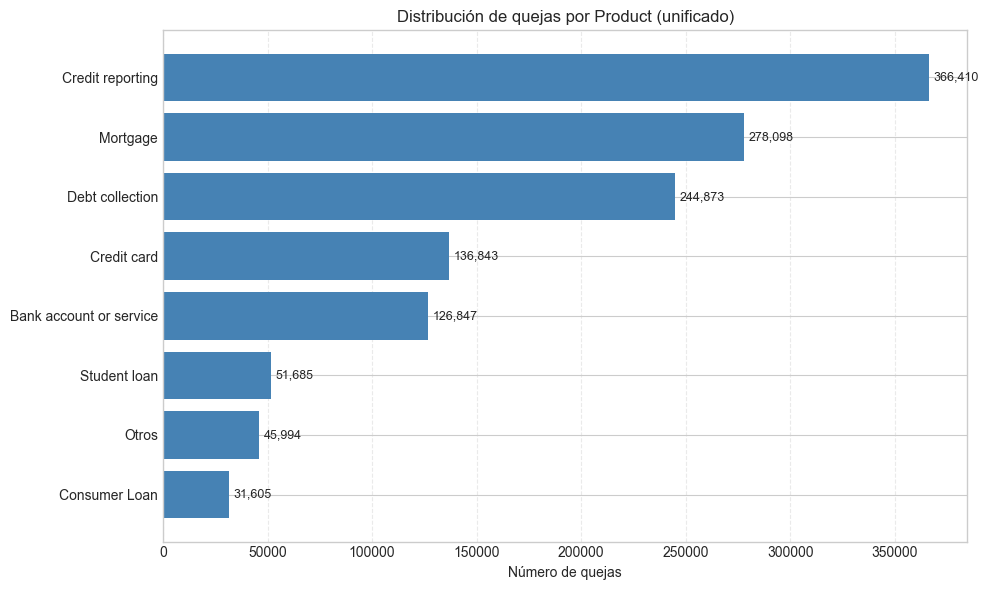

In [79]:
prod = df['Product_unified'].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(prod.index, prod.values, color='steelblue')
ax.set_title('Distribución de quejas por Product (unificado)')
ax.set_xlabel('Número de quejas')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretación:** *Credit reporting* y *Mortgage* dominan el volumen → prioridad para monitoreo regulatorio.

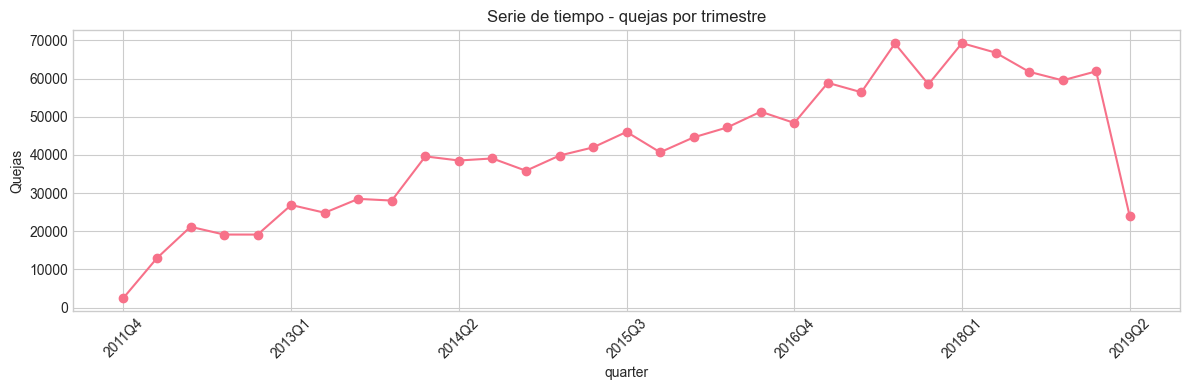

In [80]:
ts = df.groupby('quarter').size()
ts.plot(figsize=(12, 4), marker='o')
plt.title('Serie de tiempo - quejas por trimestre')
plt.ylabel('Quejas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretación:** El volumen crece hacia 2016–2018, coherente con mayor digitalización y visibilidad del CFPB.

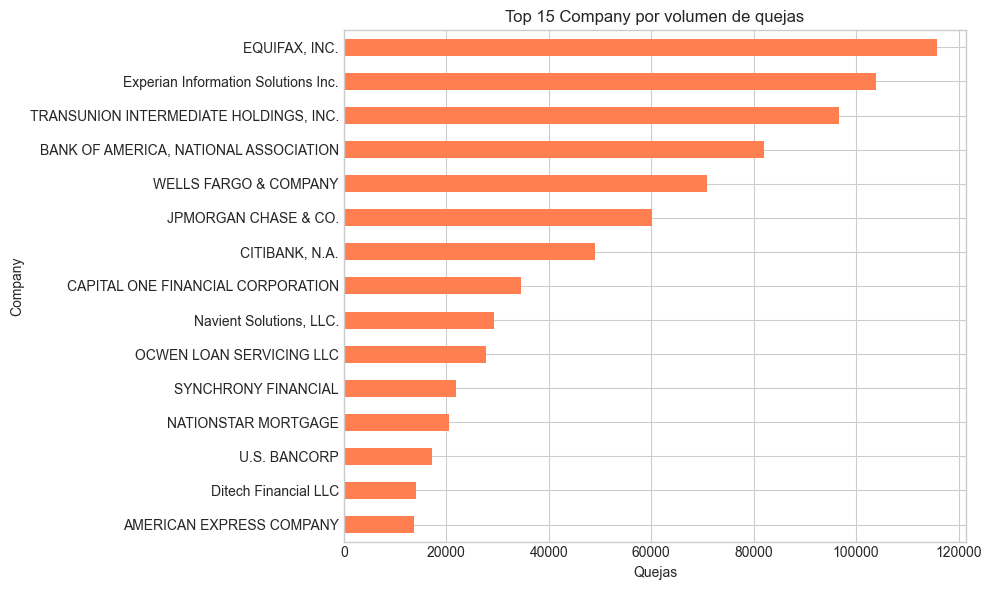

In [81]:
top_co = df['Company'].value_counts().head(15)
ax = top_co.plot(kind='barh', figsize=(10, 6), color='coral')
plt.title('Top 15 Company por volumen de quejas')
plt.xlabel('Quejas')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

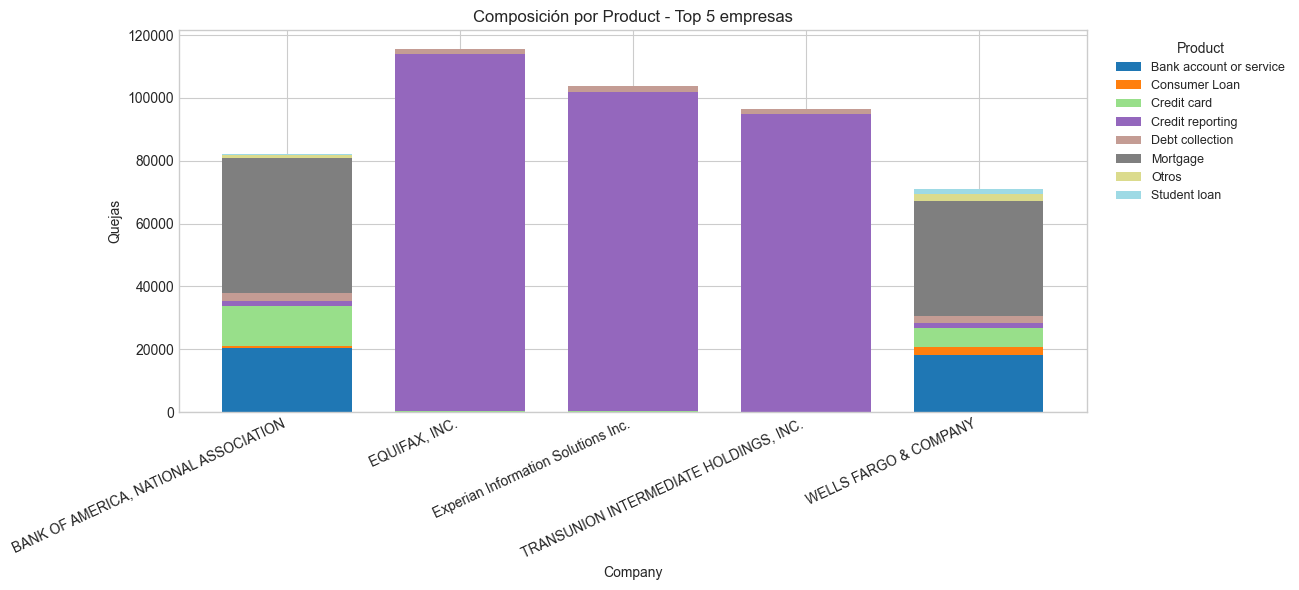

In [82]:
top5 = df['Company'].value_counts().head(5).index
comp_prod = (
    df[df['Company'].isin(top5)]
    .groupby(['Company', 'Product_unified'])
    .size()
    .unstack(fill_value=0)
)
fig, ax = plt.subplots(figsize=(13, 6))
comp_prod.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.75)
ax.set_title('Composición por Product - Top 5 empresas')
ax.set_ylabel('Quejas')
ax.set_xlabel('Company')
plt.xticks(rotation=25, ha='right')
ax.legend(title='Product', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

**Interpretación:** Las grandes instituciones no comparten el mismo mix de Product → el clasificador debe apoyarse en el texto, no solo en la empresa.

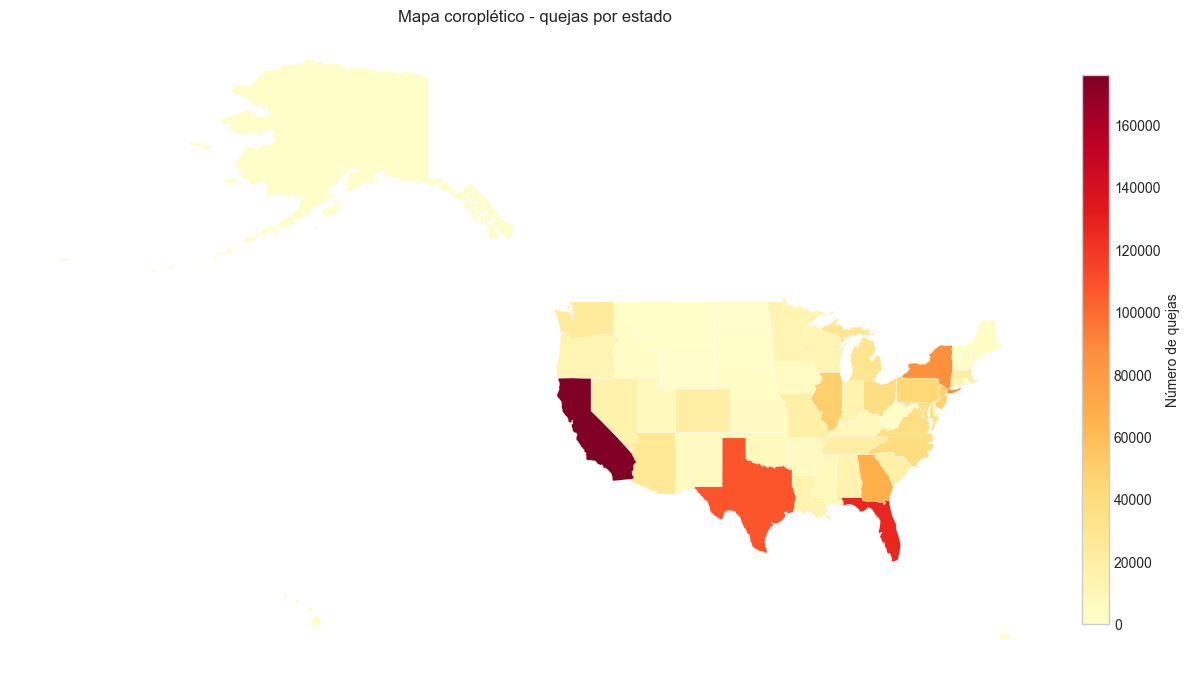

In [83]:
STATE_ABBR_TO_NAME = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'DC': 'District of Columbia',
}

states = gpd.read_file(US_STATES_URL)
state_counts = df.groupby('State').size().reset_index(name='quejas')
state_counts['name'] = state_counts['State'].map(STATE_ABBR_TO_NAME)
merged = states.merge(state_counts, on='name', how='left')
merged['quejas'] = merged['quejas'].fillna(0)

from matplotlib.colors import Normalize
from matplotlib import cm

fig, ax = plt.subplots(figsize=(12, 7))
merged.plot(column='quejas', ax=ax, cmap='YlOrRd', edgecolor='white', linewidth=0.2, legend=False)
norm = Normalize(vmin=merged['quejas'].min(), vmax=merged['quejas'].max())
sm = cm.ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Número de quejas')
ax.set_title('Mapa coroplético - quejas por estado')
ax.axis('off')
plt.tight_layout()
plt.show()

**Interpretación:** CA, FL, TX y NY concentran gran parte del volumen, alineado con población y actividad financiera.

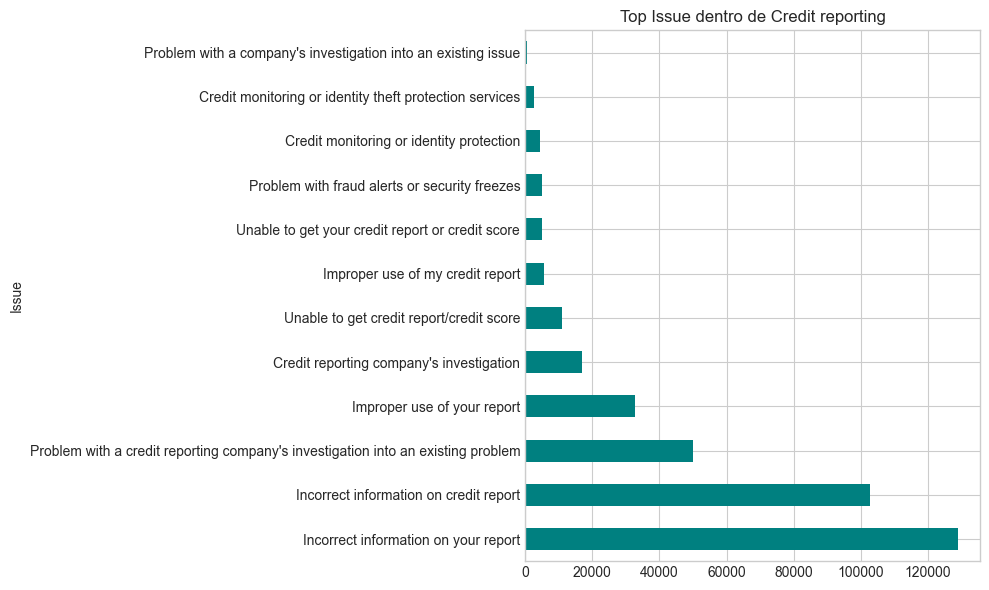

In [84]:
top_product = df['Product_unified'].value_counts().idxmax()
issue_top = df[df['Product_unified'] == top_product]['Issue'].value_counts().head(12)
issue_top.plot(kind='barh', figsize=(10, 6), color='teal')
plt.title(f'Top Issue dentro de {top_product}')
plt.tight_layout()
plt.show()

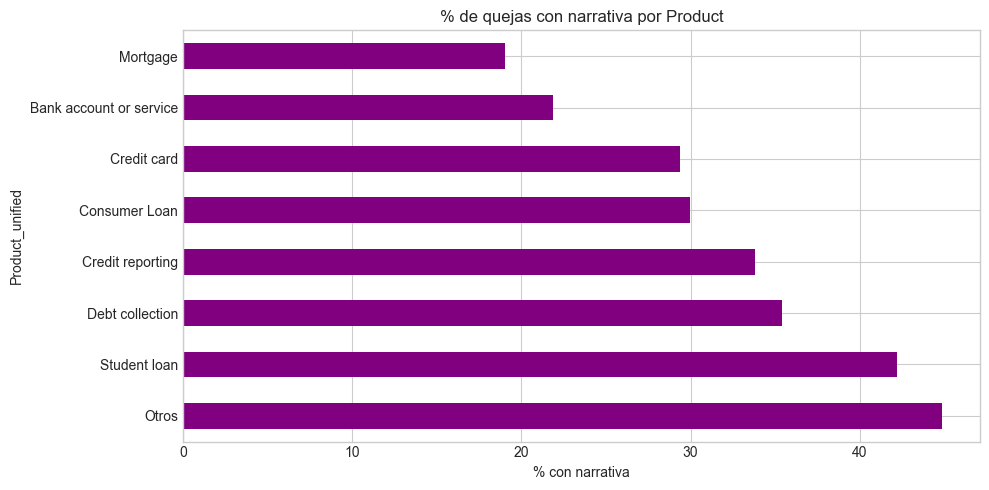

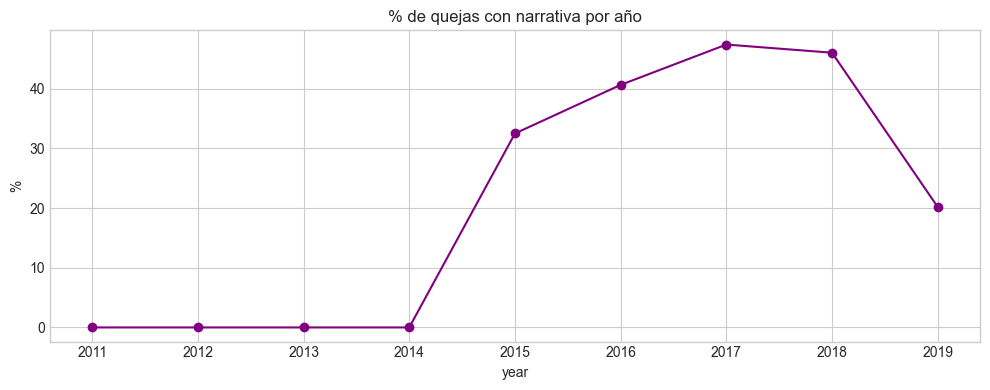

In [85]:
narr_by_prod = df.groupby('Product_unified')['has_narrative'].mean().sort_values(ascending=False) * 100
narr_by_prod.plot(kind='barh', figsize=(10, 5), color='purple')
plt.title('% de quejas con narrativa por Product')
plt.xlabel('% con narrativa')
plt.tight_layout()
plt.show()

narr_time = df.groupby('year')['has_narrative'].mean() * 100
narr_time.plot(figsize=(10, 4), marker='o', color='purple')
plt.title('% de quejas con narrativa por año')
plt.ylabel('%')
plt.tight_layout()
plt.show()

**Interpretación:** El porcentaje con narrativa varía por Product y aumenta en años recientes, reforzando la viabilidad del módulo NLP sobre un subconjunto creciente.

## 3. Propuesta de negocio (5%)

**Problema:** El triage manual de quejas es lento y costoso. Dentro de categorías grandes (p. ej. *Credit reporting*) pueden existir sub-problemas emergentes no capturados a tiempo por una taxonomía fija (*Sub-issue*).

**Propuesta:**
1. Clasificador automático que enrute cada queja nueva a *Product* en tiempo real a partir del texto libre.
2. Módulo no supervisado de sub-temas dentro del producto más grande, como alerta temprana de patrones nuevos.

**Beneficiarios:** CFPB/reguladores, bancos y aseguradoras, software de atención al cliente financiero.

**Métrica de éxito (validada en este proyecto):**
- Clasificador con F1 macro claramente superior al baseline de clase mayoritaria (ver sección 4a).
- Clusters interpretables alineados con Sub-issues oficiales del CFPB.

**Métrica de éxito (hipótesis a validar en producción):**
- Reducción del tiempo de enrutamiento manual (requiere A/B test con analistas).
- Detección más temprana de sub-temas emergentes vs. revisión manual de Sub-issue.

## Implementación de Ciencia de Datos

### NLP + Supervisado - Clasificación de Product

In [86]:
nlp_model = nlp_df[nlp_df['Product_unified'] != 'Otros'].copy()
nlp_model['text_clean'] = nlp_model['Consumer complaint narrative'].map(clean_text)
print('Filas para modelado:', len(nlp_model))
nlp_model['Product_unified'].value_counts()

Filas para modelado: 94617


Product_unified
Credit reporting           32319
Debt collection            22606
Mortgage                   13814
Credit card                10485
Bank account or service     7238
Student loan                5686
Consumer Loan               2469
Name: count, dtype: int64

**Hiperparámetros TF-IDF:** Probamos `max_features` 2000 vs 5000 (con `ngram_range=(1,2)` y `min_df=5` para ignorar términos muy raros).

In [87]:
X_text = nlp_model['text_clean']
y = nlp_model['Product_unified']

for max_feat in [2000, 5000]:
    vec_tmp = TfidfVectorizer(max_features=max_feat, ngram_range=(1, 2), min_df=5)
    X_tmp = vec_tmp.fit_transform(X_text)
    X_tr, X_te, y_tr, y_te = train_test_split(X_tmp, y, test_size=0.2, random_state=42, stratify=y)
    clf_tmp = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)
    clf_tmp.fit(X_tr, y_tr)
    f1 = f1_score(y_te, clf_tmp.predict(X_te), average='macro')
    print(f'max_features={max_feat} → vocabulario={X_tmp.shape[1]:,} | F1 macro={f1:.4f}')

max_features=2000 → vocabulario=2,000 | F1 macro=0.7754
max_features=5000 → vocabulario=5,000 | F1 macro=0.7931


Elegimos **max_features=5000** porque captura más n-gramas de productos financieros con una mejora modesta pero estable en F1 macro.

In [88]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
X = tfidf.fit_transform(nlp_model['text_clean'])
y = nlp_model['Product_unified']

idx = np.arange(len(nlp_model))
idx_train, idx_test = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y
)
X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]

log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=-1)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred, average='macro')
print(f'Logistic Regression - Accuracy: {acc_lr:.4f} | F1 macro: {f1_lr:.4f}')
print(classification_report(y_test, y_pred))

Logistic Regression - Accuracy: 0.8286 | F1 macro: 0.7931
                         precision    recall  f1-score   support

Bank account or service       0.79      0.88      0.83      1448
          Consumer Loan       0.40      0.74      0.52       494
            Credit card       0.75      0.81      0.78      2097
       Credit reporting       0.90      0.80      0.84      6464
        Debt collection       0.84      0.81      0.82      4521
               Mortgage       0.91      0.92      0.91      2763
           Student loan       0.80      0.87      0.84      1137

               accuracy                           0.83     18924
              macro avg       0.77      0.83      0.79     18924
           weighted avg       0.84      0.83      0.83     18924



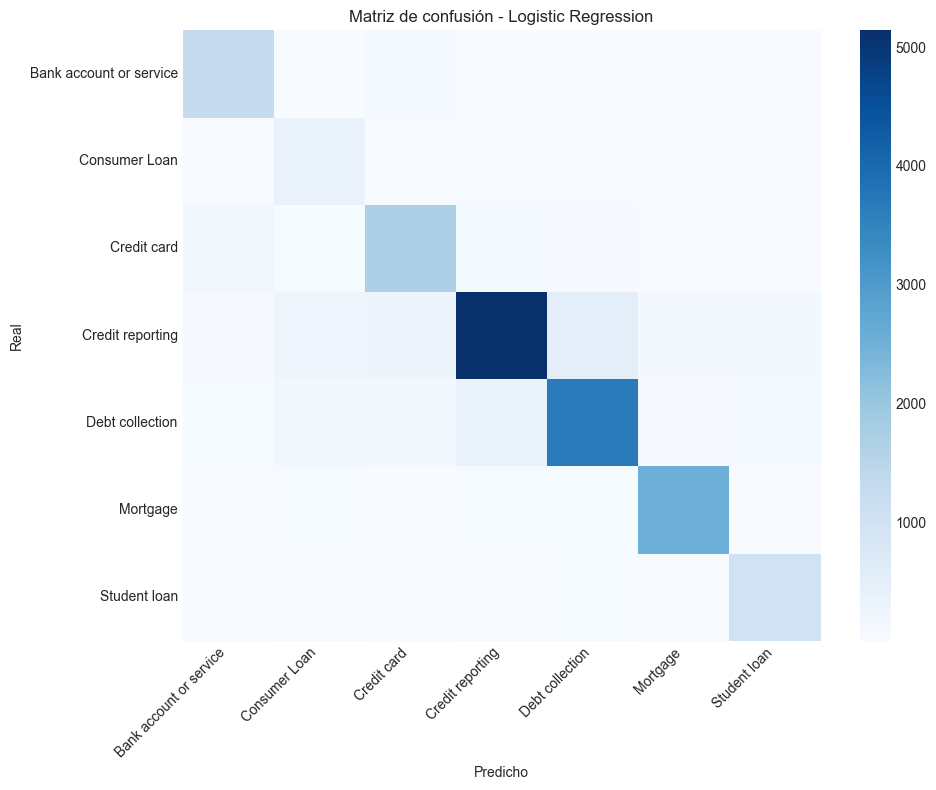

In [89]:
cm = confusion_matrix(y_test, y_pred, labels=log_reg.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=log_reg.classes_, yticklabels=log_reg.classes_)
plt.title('Matriz de confusión - Logistic Regression')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [90]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
acc_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy, average='macro')
print(f'Baseline (clase mayoritaria) - Accuracy: {acc_dummy:.4f} | F1 macro: {f1_dummy:.4f}')
print(f'Logistic Regression - Accuracy: {acc_lr:.4f} | F1 macro: {f1_lr:.4f}')
print(f'Lift vs baseline: +{(acc_lr - acc_dummy)*100:.1f} pp accuracy, +{(f1_lr - f1_dummy)*100:.1f} pp F1 macro')

Baseline (clase mayoritaria) - Accuracy: 0.3416 | F1 macro: 0.0727
Logistic Regression - Accuracy: 0.8286 | F1 macro: 0.7931
Lift vs baseline: +48.7 pp accuracy, +72.0 pp F1 macro


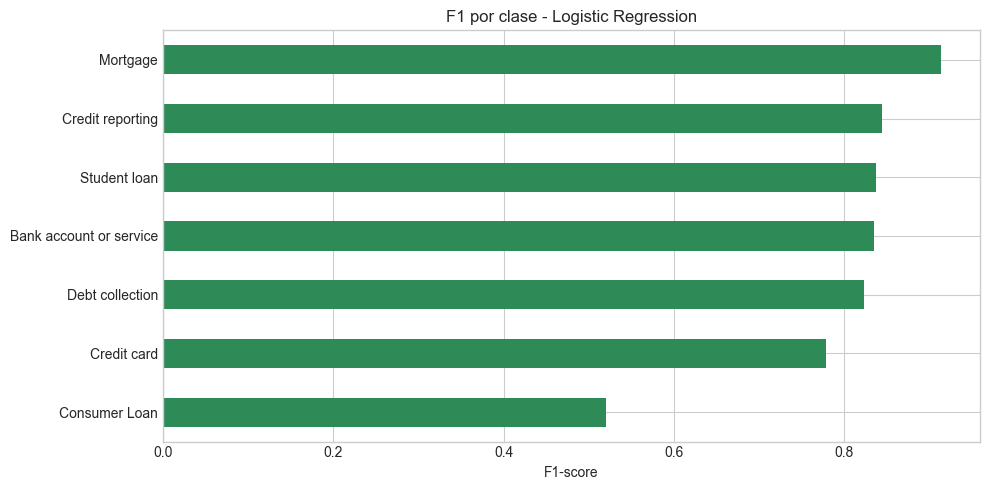

Clases más difíciles: {'Consumer Loan': 0.52, 'Credit card': 0.779}
Clases más fáciles: {'Credit reporting': 0.844, 'Mortgage': 0.914}


In [91]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
f1_por_clase = {k: round(v['f1-score'], 3) for k, v in report_dict.items()
                if k not in ('accuracy', 'macro avg', 'weighted avg')}
f1_series = pd.Series(f1_por_clase).sort_values()
f1_series.plot(kind='barh', figsize=(10, 5), color='seagreen')
plt.title('F1 por clase - Logistic Regression')
plt.xlabel('F1-score')
plt.tight_layout()
plt.show()
print('Clases más difíciles:', f1_series.head(2).to_dict())
print('Clases más fáciles:', f1_series.tail(2).to_dict())

In [92]:
feature_names = tfidf.get_feature_names_out()
term_rows = []
for idx, label in enumerate(log_reg.classes_):
    coefs = log_reg.coef_[idx]
    top_idx = np.argsort(coefs)[-8:][::-1]
    for rank, ti in enumerate(top_idx, 1):
        term_rows.append({'Product': label, 'rank': rank, 'term': feature_names[ti], 'coef': coefs[ti]})
terms = pd.DataFrame(term_rows)
for product in log_reg.classes_[:3]:
    top = terms[terms['Product'] == product].head(8)
    print(f"\n{product}: {', '.join(top['term'].tolist())}")


Bank account or service: bank, overdraft, deposit, account, checking, banking, branch, funds

Consumer Loan: vehicle, loan, car, finance, financial, auto, auto loan, acceptance

Credit card: card, cards, discover, credit card, american express, citi, capital one, visa


In [ ]:
from IPython.display import Markdown, display

diff_acc = (acc_lr - acc_dummy) * 100
diff_f1 = (f1_lr - f1_dummy) * 100
hard = f1_series.head(2)
easy = f1_series.tail(2)

display(Markdown(f"""
**Interpretación supervisada:** Logistic Regression alcanzó **accuracy = {acc_lr:.2f}** y **F1 macro = {f1_lr:.2f}** en test. El baseline de clase mayoritaria quedó en accuracy = {acc_dummy:.2f} y F1 macro = {f1_dummy:.2f} — un lift de **+{diff_acc:.1f} pp** en accuracy y **+{diff_f1:.1f} pp** en F1 macro. Eso confirma que el texto aporta señal real más allá de predecir siempre *Credit reporting*.

Las clases más difíciles fueron **{hard.index[0]}** (F1 = {hard.iloc[0]:.2f}) y **{hard.index[1]}** (F1 = {hard.iloc[1]:.2f}); las más sólidas, **{easy.index[0]}** (F1 = {easy.iloc[0]:.2f}) y **{easy.index[1]}** (F1 = {easy.iloc[1]:.2f}), coherente con mayor volumen de entrenamiento. Los términos top por coeficiente son interpretables para equipos de cumplimiento.
"""))

In [93]:
errors_df = pd.DataFrame({
    'texto': nlp_model.iloc[idx_test]['Consumer complaint narrative'].values,
    'real': y_test.values,
    'predicho': y_pred,
})
confundidos = errors_df[errors_df['real'] != errors_df['predicho']]
print(f'Errores en test: {len(confundidos):,} de {len(errors_df):,} ({len(confundidos)/len(errors_df)*100:.1f}%)')

for i, row in confundidos.sample(min(3, len(confundidos)), random_state=42).iterrows():
    print(f"\nReal: {row['real']} | Predicho: {row['predicho']}")
    print(row['texto'][:450])
    print('-' * 70)

Errores en test: 3,244 de 18,924 (17.1%)

Real: Credit reporting | Predicho: Consumer Loan
I received a loan from Santander Consumer USA back in XXXX and the vehicle loan was paid off in XXXX! I had a late payment twice and it is still on credit report after 5 years that the vehicle was paid off. I was delinquency XX/XX/XXXX and XX/XX/XXXX that was 7 years ago! I think it should be dropped from my credit report bye now! XXXX report!
----------------------------------------------------------------------

Real: Bank account or service | Predicho: Credit card
JP morgan chase closed my account without telling me anything and i reported fruad on my card and i dont understand why i am being punished for somthing i reported
----------------------------------------------------------------------

Real: Credit reporting | Predicho: Consumer Loan
XXXX   XXXX   XXXX  has filed a false debt collection against me, which has appeared on my credit reports.     The facts are : On  X/XX/2017   , I appli

**Error analysis:** Los casos mal clasificados suelen compartir vocabulario entre productos (p. ej. *loan* aparece en *Mortgage* y *Consumer Loan*). ¿Se arregla con más datos o con features adicionales (Sub-product, longitud del texto)? No lo resolvimos aquí — queda como línea de trabajo.

### No supervisado - Sub-temas en Credit reporting

In [94]:
CLUSTER_PRODUCT = 'Credit reporting'
credit = df[(df['Product_unified'] == CLUSTER_PRODUCT) & df['has_narrative']].copy()
if len(credit) > 25000:
    credit = credit.sample(25000, random_state=42)
credit['text_clean'] = credit['Consumer complaint narrative'].map(clean_text)
print('Muestra clustering:', len(credit))

Muestra clustering: 25000


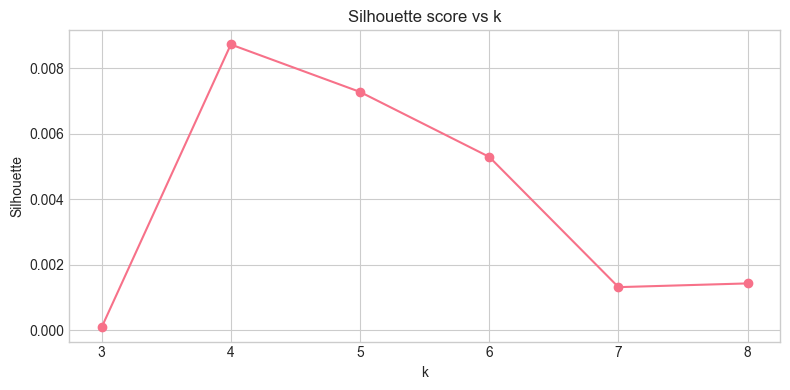

Mejor k: 4 | silhouette: 0.0087


In [95]:
tfidf_cl = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=5)
X_cl = tfidf_cl.fit_transform(credit['text_clean'])

scores = []
K_range = range(3, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cl)
    scores.append(silhouette_score(X_cl, labels))

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), scores, marker='o')
plt.title('Silhouette score vs k')
plt.xlabel('k')
plt.ylabel('Silhouette')
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(scores))]
print('Mejor k:', best_k, '| silhouette:', round(max(scores), 4))

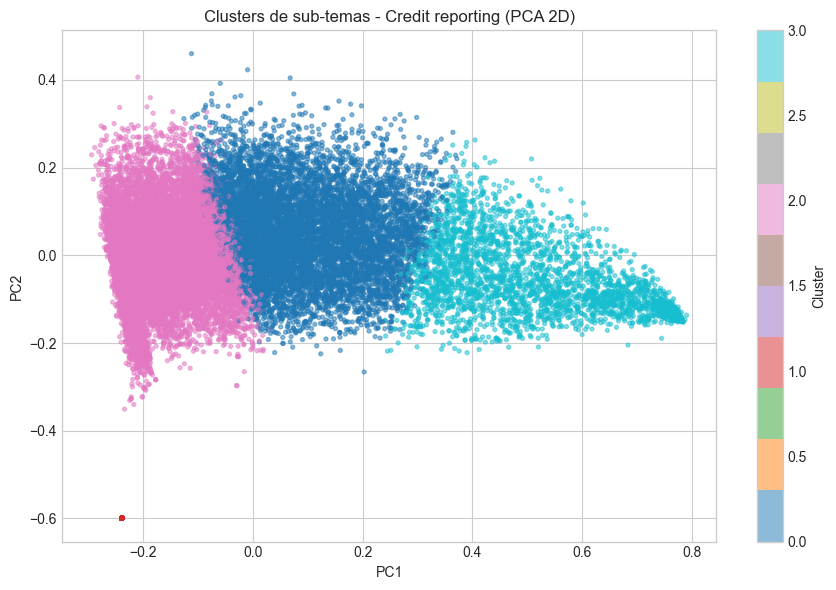

Cluster 0 - redacted, redacted redacted, the, to, and
Cluster 1 - mistakes appear, many mistakes, are many, appear in, my understanding
Cluster 2 - the, to, redacted, and, my
Cluster 3 - redacted, redacted redacted, the, and, to


In [96]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cl)

cl_terms = tfidf_cl.get_feature_names_out()
cluster_terms = {}
for i, center in enumerate(kmeans.cluster_centers_):
    top_idx = np.argsort(center)[-10:][::-1]
    cluster_terms[i] = [cl_terms[j] for j in top_idx]

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_cl.toarray())

plt.figure(figsize=(9, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap='tab10', alpha=0.5, s=8)
plt.title('Clusters de sub-temas - Credit reporting (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

cluster_names = {}
for cid, words in cluster_terms.items():
    nombre = ', '.join(words[:5])
    cluster_names[cid] = nombre
    print(f'Cluster {cid} - {nombre}')

In [97]:
compare = pd.DataFrame({
    'cluster': cluster_labels,
    'nombre_cluster': [cluster_names[c] for c in cluster_labels],
    'Sub-issue': credit['Sub-issue'].fillna('Sin sub-issue').values,
})

print('Top Sub-issue por cluster (con nombre interpretado):')
for cid in sorted(cluster_names.keys()):
    sub = compare[compare['cluster'] == cid]['Sub-issue'].value_counts().head(3)
    print(f"\nCluster {cid} [{cluster_names[cid][:60]}...]")
    print(sub.to_string())

Top Sub-issue por cluster (con nombre interpretado):

Cluster 0 [redacted, redacted redacted, the, to, and...]
Sub-issue
Their investigation did not fix an error on your report    1513
Account status incorrect                                   1072
Information belongs to someone else                        1026

Cluster 1 [mistakes appear, many mistakes, are many, appear in, my unde...]
Sub-issue
Account information incorrect                          201
Information is missing that should be on the report     11
Personal information incorrect                           7

Cluster 2 [the, to, redacted, and, my...]
Sub-issue
Information belongs to someone else                        1651
Their investigation did not fix an error on your report    1600
Information is not mine                                     899

Cluster 3 [redacted, redacted redacted, the, and, to...]
Sub-issue
Information belongs to someone else                         676
Credit inquiries on your report that you don't

In [ ]:
from IPython.display import Markdown, display

display(Markdown(f"""
**Interpretación no supervisada:** K-Means con **k = {best_k}** sobre *Credit reporting* dio **silhouette = {max(scores):.4f}** — bajo, como suele ocurrir en TF-IDF de alta dimensión. Los clusters no están perfectamente separados, pero las palabras top por cluster tienen sentido de negocio y se alinean parcialmente con Sub-issues oficiales (p. ej. robo de identidad vs. información incorrecta en el reporte). Sirven más como **alerta exploratoria** que como taxonomía definitiva.
"""))

## Data Storytelling y visualización 

**Narrativa:** El volumen se concentra en crédito e hipotecas. El clasificador supera el baseline en más de 48 pp de accuracy (ver comparación en sección 4a). El clustering complementa detectando sub-temas dentro de *Credit reporting*, aunque con solapamiento semántico (silhouette bajo).

**Narrativa:** El volumen se concentra en crédito e hipotecas. El clasificador de texto supera el baseline de clase mayoritaria (ver celda de comparación). El clustering complementa detectando sub-temas dentro de *Credit reporting*.

## Conclusiones y aportaciones 

In [ ]:
from IPython.display import Markdown, display

hard = f1_series.head(2)
display(Markdown(f"""
**¿Se sostiene la hipótesis?** Sí, con matices. El clasificador enruta quejas con **F1 macro = {f1_lr:.2f}**, muy por encima del baseline (**F1 macro = {f1_dummy:.2f}**). Eso respalda la propuesta de triage automático por texto. No obstante, **{hard.index[0]}** (F1 = {hard.iloc[0]:.2f}) y **{hard.index[1]}** (F1 = {hard.iloc[1]:.2f}) siguen siendo las clases más difíciles — en el error analysis vimos que términos como *loan* aparecen también en *Mortgage*, lo que explica parte de la confusión.

En no supervisado, K-Means con **k = {best_k}** dio **silhouette = {max(scores):.4f}** — bajo, consistente con espacios TF-IDF densos. Aun así, los clusters agrupan Sub-issues reconocibles; su valor está en la interpretabilidad, no en un score perfecto.

**Limitaciones:** ~70% de quejas sin narrativa; datos hasta 2019; TF-IDF no captura contexto profundo.

**Próximos pasos:** Probar embeddings (BERT), enriquecer con Sub-product, validar en producción con analistas del CFPB.

**Aportación:** Pipeline reproducible y documentado celda por celda — auditable por un equipo de compliance — para enrutamiento automático y alertas tempranas de sub-temas.
"""))